# Week 10 Lab: Logistic Regression and Classification Evaluation

<a href="https://colab.research.google.com/github/bradleyboehmke/uc-bana-4080/blob/main/labs/10_wk10_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Welcome to Week 10! This lab serves as both your Thursday class session and your homework for the week. You'll apply logistic regression and classification evaluation techniques to two important business scenarios: credit risk assessment and medical diagnosis support.

In the business world, classification problems are everywhere—from determining loan approvals to medical screenings. Today you'll master the complete workflow from data preparation through model evaluation, learning to choose appropriate metrics that align with business objectives and costs.

## 🎯 Learning Objectives
By the end of this lab, you will be able to:
- Apply the complete logistic regression workflow: data preparation, model fitting, and interpretation
- Calculate and interpret baseline ratios for imbalanced classification problems
- Evaluate classification models using precision, recall, F1-score, and ROC-AUC metrics
- Select appropriate evaluation metrics based on business context and error costs

## 📚 This Lab Reinforces
- **Chapter 23: Introduction to Logistic Regression for Classification**
- **Chapter 24: Evaluating Classification Models**
- **Tuesday's Lecture: Classification Methods and Model Evaluation**

## 🕐 Estimated Time & Structure
**Total Time:** 75 minutes  
**Mode:** Individual work (this serves as your homework)

- **[0–10 min]** Review: Default dataset logistic regression workflow
- **[10–35 min]** Application: Breast Cancer Wisconsin dataset analysis
- **[35–70 min]** Independent challenges: Specific homework questions
- **[70–75 min]** Wrap-up and submission preparation

## 💡 Why This Matters
Classification problems drive critical business decisions across industries. Credit companies need to assess default risk, healthcare systems require diagnostic support, and marketing teams must identify likely customers. The ability to build, evaluate, and interpret classification models—while understanding the business implications of different types of errors—is essential for data-driven decision making. Today's lab prepares you to tackle these real-world challenges with confidence.

## Setup
We'll work with two datasets: the Default dataset from ISLP (for review) and the Breast Cancer Wisconsin dataset (for our main analysis). Both represent important classification scenarios in business and healthcare.

In [3]:
# Required imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)

!pip install ISLP
from ISLP import load_data
import warnings
warnings.filterwarnings('ignore')

# Set random state for reproducibility
RANDOM_STATE = 42

print("✅ All libraries imported successfully!")
print("🎯 Ready to dive into classification analysis!")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.8 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=0b4ec009e030e65ec19ed08d510c03749f4d947d9f6dad936c78fb99e4b1845e
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma
✅ All libraries imported successfully!
🎯 Ready to dive into classification analysis!


## Part 1 — Review: Default Dataset Logistic Regression (10 minutes)

Let's quickly review the complete logistic regression workflow using the Default dataset from Chapters 23-24. This will reinforce the key concepts before we tackle the main dataset.

### Quick Workflow Review

We'll walk through each step systematically:

**📋 Step-by-step process:**
1. Load data and compute baseline ratio
2. Prepare features with dummy encoding
3. Split data into training and test sets
4. Fit logistic regression model and interpret coefficients
5. Make predictions and evaluate using multiple metrics

In [4]:
# Step 1: Load Default dataset and examine baseline
Default = load_data('Default')

print("Default Dataset Overview:")
print(f"Shape: {Default.shape}")
print(f"\nColumns: {Default.columns.tolist()}")
print(f"\nFirst few rows:")
print(Default.head())

# Compute baseline ratio
baseline_default_rate = (Default['default'] == 'Yes').mean()
print(f"\n📊 Baseline Analysis:")
print(f"Default rate: {baseline_default_rate:.1%}")
print(f"Non-default rate: {1-baseline_default_rate:.1%}")

Default Dataset Overview:
Shape: (10000, 4)

Columns: ['default', 'student', 'balance', 'income']

First few rows:
  default student      balance        income
0      No      No   729.526495  44361.625074
1      No     Yes   817.180407  12106.134700
2      No      No  1073.549164  31767.138947
3      No      No   529.250605  35704.493935
4      No      No   785.655883  38463.495879

📊 Baseline Analysis:
Default rate: 3.3%
Non-default rate: 96.7%


In [5]:
# Step 2: Prepare data with dummy encoding
# Convert categorical variables to numeric
Default_encoded = pd.get_dummies(Default, columns=['student'], drop_first=True)
Default_encoded['default_binary'] = (Default_encoded['default'] == 'Yes').astype(int)

# Define features and target
X = Default_encoded[['balance', 'income', 'student_Yes']]
y = Default_encoded['default_binary']

print("Data Preparation Complete:")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")

Data Preparation Complete:
Features shape: (10000, 3)
Target shape: (10000,)

Feature columns: ['balance', 'income', 'student_Yes']


In [6]:
# Step 3: Split data (70-30 split as specified for homework questions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE
)

print(f"📊 Data Split Results:")
print(f"Training set: {len(X_train):,} observations")
print(f"Test set: {len(X_test):,} observations")
print(f"\nTraining set default rate: {y_train.mean():.1%}")
print(f"Test set default rate: {y_test.mean():.1%}")

📊 Data Split Results:
Training set: 7,000 observations
Test set: 3,000 observations

Training set default rate: 3.4%
Test set default rate: 3.1%


In [7]:
# Step 4: Fit logistic regression model
model = LogisticRegression(random_state=RANDOM_STATE)
model.fit(X_train, y_train)

# Extract and interpret coefficients
print("🔍 Model Coefficients:")
print(f"Intercept: {model.intercept_[0]:.6f}")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef:.6f}")

print(f"\n💡 Interpretation:")
print(f"• Balance: Positive coefficient means higher balance increases default risk")
print(f"• Income: Very small coefficient suggests minimal impact after accounting for balance")
print(f"• Student: Negative coefficient means students have lower default risk (holding other factors constant)")

🔍 Model Coefficients:
Intercept: -11.108164
balance: 0.005789
income: 0.000006
student_Yes: -0.467459

💡 Interpretation:
• Balance: Positive coefficient means higher balance increases default risk
• Income: Very small coefficient suggests minimal impact after accounting for balance
• Student: Negative coefficient means students have lower default risk (holding other factors constant)


In [8]:
# Step 5: Make predictions and evaluate comprehensively
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate all key metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("📈 Model Performance Metrics:")
print(f"Accuracy:  {accuracy:.1%}")
print(f"Precision: {precision:.1%}")
print(f"Recall:    {recall:.1%}")
print(f"F1-Score:  {f1:.1%}")
print(f"ROC-AUC:   {auc:.3f}")

print(f"\n💡 What These Metrics Mean for Credit Risk:")
print(f"• Accuracy (97.3%): Overall correctness - 97.3% of all predictions are correct")
print(f"• Precision (69.4%): Of customers flagged as 'will default', 69.4% actually do")
print(f"  → Low false alarms but still 30.6% false positives")
print(f"• Recall (26.6%): Only catches 26.6% of actual defaulters")
print(f"  → Misses 73.4% of customers who will default - major business risk!")
print(f"• F1-Score (38.5%): Balanced measure showing poor overall classification performance")
print(f"• ROC-AUC (0.947): Excellent ability to rank customers by default risk")
print(f"  → Model is very good at scoring, but default threshold may need adjustment")

# Show confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\n🔍 Confusion Matrix:")
print(f"[[{cm[0,0]:4d}, {cm[0,1]:3d}]]")
print(f"[[{cm[1,0]:4d}, {cm[1,1]:3d}]]")
print(f"\nThis shows: TN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]}")
print(f"Business Impact: {cm[1,0]} defaulters missed (lost revenue), {cm[0,1]} customers wrongly rejected (lost business)")

📈 Model Performance Metrics:
Accuracy:  97.3%
Precision: 69.4%
Recall:    26.6%
F1-Score:  38.5%
ROC-AUC:   0.947

💡 What These Metrics Mean for Credit Risk:
• Accuracy (97.3%): Overall correctness - 97.3% of all predictions are correct
• Precision (69.4%): Of customers flagged as 'will default', 69.4% actually do
  → Low false alarms but still 30.6% false positives
• Recall (26.6%): Only catches 26.6% of actual defaulters
  → Misses 73.4% of customers who will default - major business risk!
• F1-Score (38.5%): Balanced measure showing poor overall classification performance
• ROC-AUC (0.947): Excellent ability to rank customers by default risk
  → Model is very good at scoring, but default threshold may need adjustment

🔍 Confusion Matrix:
[[2895,  11]]
[[  69,  25]]

This shows: TN=2895, FP=11, FN=69, TP=25
Business Impact: 69 defaulters missed (lost revenue), 11 customers wrongly rejected (lost business)


## Part 2 — Main Analysis: Breast Cancer Wisconsin Dataset (25 minutes)

Now let's apply these skills to a new healthcare dataset. The **Breast Cancer Wisconsin (Diagnostic) dataset** contains features computed from digitized images of fine needle aspirate (FNA) of breast masses. Our goal is to predict whether a tumor is **malignant** (cancerous) or **benign** (non-cancerous).

### 🔬 About This Dataset

**Data Source**: Originally created by Dr. William H. Wolberg, W. Nick Street, and Olvi L. Mangasarian at the University of Wisconsin-Madison. This dataset is widely used in machine learning research and medical informatics.

**Data Collection Process**: For each breast mass sample, a fine needle aspirate (FNA) was performed, then digitized images were analyzed to compute quantitative features describing the cell nuclei characteristics.

### 📊 Feature Categories

The dataset contains **30 quantitative features** organized into three groups for each characteristic:

1. **Mean values** (`_mean`): Average across all cells in the sample
2. **Standard error** (`_se`): Standard error of the measurements  
3. **Worst values** (`_worst`): Mean of the three largest (most severe) values

**The 10 core characteristics measured are:**

- **`radius`**: Distance from center to perimeter points
- **`texture`**: Standard deviation of gray-scale values  
- **`perimeter`**: Total boundary length of the cell nucleus
- **`area`**: Total area enclosed by the cell nucleus boundary
- **`smoothness`**: Local variation in radius lengths
- **`compactness`**: (perimeter² / area) - 1.0, measuring shape regularity
- **`concavity`**: Severity of concave portions of the boundary
- **`concave_points`**: Number of concave portions of the boundary
- **`symmetry`**: Bilateral symmetry of the cell nucleus
- **`fractal_dimension`**: Fractal complexity using coastline approximation

### 🎯 Simplified Analysis Focus

For this part of the lab, we'll focus on the **5 mean features** to keep our analysis manageable:
- `radius_mean`, `texture_mean`, `perimeter_mean`, `area_mean`, `smoothness_mean`

These provide a representative sample of size, texture, and shape characteristics that are clinically relevant for distinguishing malignant from benign tumors.

**Business Context**: In medical diagnosis, the costs of different errors are dramatically different. Missing a malignant tumor (false negative) can be life-threatening, while incorrectly flagging a benign tumor as malignant (false positive) leads to unnecessary stress and additional testing costs.

### Exercise 2.1: Data Loading and Exploration

**Your Task**: Load the breast cancer dataset and perform initial exploratory analysis.

**Instructions**:
1. Load the dataset from the provided URL
2. Examine the dataset structure (shape, columns, first few rows)
3. Calculate the baseline ratio of malignant vs benign diagnoses
4. Check for any missing values in the dataset

**Questions to Answer**:
- How many observations and features does the dataset contain?
- What percentage of cases are malignant vs benign?
- Are there any missing values that need to be handled?

Write your code below to answer these questions:

In [12]:
# Exercise 2.1: Your code here

# URL for the breast cancer dataset
url = "https://raw.githubusercontent.com/bradleyboehmke/uc-bana-4080/refs/heads/main/data/breast_cancer.csv"

# Task 1: Load the dataset (PROVIDED)
cancer_data = pd.read_csv(url)
print("✅ Breast Cancer Wisconsin dataset loaded successfully!")

# Task 2: Examine dataset structure (shape, columns, first few rows)
# Write your code here
diagnositcs = cancer_data['diagnosis'].value_counts()
print(f"📊 Dataset Structure:")
print(f"Shape: {cancer_data.shape}")
print(f"Columns: {cancer_data.columns.tolist()}")
print(f"First few rows:")
print(cancer_data.head())


# Task 3: Calculate baseline ratio of malignant vs benign diagnoses
# Write your code here
diagnostics = cancer_data['diagnosis'].value_counts()
print(f"\n📊 Baseline Analysis:")
print(f"Malignant: {diagnostics['M'] / len(cancer_data):.1%}")
print(f"Benign: {diagnostics['B'] / len(cancer_data):.1%}")


# Task 4: Check for missing values
# Write your code here
print("\nMissing values in dataset:\n", cancer_data.isnull().sum())

✅ Breast Cancer Wisconsin dataset loaded successfully!
📊 Dataset Structure:
Shape: (569, 31)
Columns: ['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']
First few rows:
  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0         M        17.99         10.38          122.80     1001.0   
1         M        20.57         17.77          132.90     1326.0   
2         M        19.69         21.25          130.00     1203.0   
3         M        11.42         20.38         

In [ ]:
# Solution will be provided by TA during lab

# This cell will contain the solution code that the TA will walk through
# Students should attempt the exercise above before seeing the solution

print("✅ TA will provide solution during lab walkthrough")

### Exercise 2.2: Data Preparation and Modeling (Using Mean Features Only)

**Your Task**: Prepare the breast cancer data for logistic regression analysis using only the `_mean` features.

**Background**: For this exercise, we'll focus on a subset of features to keep the analysis manageable. You'll work with the 10 `_mean` features, which represent the average measurements across all cells in each sample.

**Instructions**:
1. Create a binary target variable (0=Benign, 1=Malignant) from the diagnosis column
2. Select only the features ending with `_mean` for your feature matrix
3. Split the data into training and test sets (70-30 split)
4. Fit a logistic regression model and examine the coefficients
5. Make predictions on the test set

**Important**: Use `RANDOM_STATE` variable (defined at the beginning) for consistent results across all students.

**Questions to Answer**:
- How many `_mean` features are available in the dataset?
- What are the training and test set sizes after the split?
- Which `_mean` features have positive vs negative coefficients?
- What do the coefficient signs suggest about malignancy risk?

Write your code below to complete these tasks:

In [13]:
# Exercise 2.2: Your code here
# Assume the cancer_data DataFrame is available from Exercise 2.1

# Task 1: Create binary target variable (0=Benign, 1=Malignant)
cancer_data['diagnosis_binary'] = (cancer_data['diagnosis'] == 'M').astype(int)
y_cancer = cancer_data['diagnosis_binary']

# Task 2: Select only the features ending with '_mean' (PROVIDED)
mean_features = [col for col in cancer_data.columns if col.endswith('_mean')]
X_cancer_mean = cancer_data[mean_features]
print(f"✅ Selected {len(mean_features)} mean features:")
print(f"Features: {mean_features}")

# Task 3: Split data into training and test sets (70-30 split using RANDOM_STATE)
X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = train_test_split(
    X_cancer_mean, y_cancer, test_size=0.3, random_state=RANDOM_STATE,
    stratify=y_cancer # Stratify to maintain class balance
)

print(f"\n📊 Data Split Results:")
print(f"Training set: {len(X_train_cancer):,} observations")
print(f"Test set: {len(X_test_cancer):,} observations")
print(f"\nTraining set malignant rate: {y_train_cancer.mean():.1%}")
print(f"Test set malignant rate: {y_test_cancer.mean():.1%}")

# Task 4: Fit logistic regression model and examine coefficients
model_mean_features = LogisticRegression(random_state=RANDOM_STATE, solver='liblinear', max_iter=1000)
model_mean_features.fit(X_train_cancer, y_train_cancer)

print("\n🔍 Model Coefficients (Mean Features Only):")
print(f"Intercept: {model_mean_features.intercept_[0]:.6f}")
for feature, coef in zip(X_cancer_mean.columns, model_mean_features.coef_[0]):
    print(f"{feature}: {coef:.6f}")

print(f"\n💡 Interpretation:")
print(f"• Positive coefficients suggest higher values of the feature increase malignancy risk.")
print(f"• Negative coefficients suggest higher values of the feature decrease malignancy risk.")

# Task 5: Make predictions on test set
y_pred_cancer = model_mean_features.predict(X_test_cancer)
y_pred_proba_cancer = model_mean_features.predict_proba(X_test_cancer)[:, 1]

print("\n✅ Predictions made on the test set.")

✅ Selected 10 mean features:
Features: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']

📊 Data Split Results:
Training set: 398 observations
Test set: 171 observations

Training set malignant rate: 37.2%
Test set malignant rate: 37.4%

🔍 Model Coefficients (Mean Features Only):
Intercept: -0.615074
radius_mean: -3.964206
texture_mean: 0.166453
perimeter_mean: 0.402629
area_mean: 0.024493
smoothness_mean: 0.415378
compactness_mean: 0.948809
concavity_mean: 1.330575
concave points_mean: 0.735593
symmetry_mean: 0.524726
fractal_dimension_mean: 0.098868

💡 Interpretation:
• Positive coefficients suggest higher values of the feature increase malignancy risk.
• Negative coefficients suggest higher values of the feature decrease malignancy risk.

✅ Predictions made on the test set.


In [ ]:
# Solution will be provided by TA during lab

# This cell will contain the solution code that the TA will walk through
# Students should attempt Exercise 2.2 above before seeing the solution

print("✅ TA will provide solution during lab walkthrough")

### Exercise 2.3: Model Evaluation

**Your Task**: Evaluate the performance of your logistic regression model using multiple classification metrics.

**Instructions**:
1. Calculate accuracy, precision, recall, and F1-score on the test set
2. Calculate the ROC-AUC score
3. Create and interpret the confusion matrix
4. Discuss which metrics are most important for medical diagnosis

**Questions to Answer**:
- What is the model's performance across different metrics?
- In the context of cancer diagnosis, which type of error (false positive vs false negative) is more concerning?
- How does this model's performance compare to the baseline?

Write your code below to evaluate the model:

In [14]:
# Exercise 2.3: Your code here
# Assume you have y_test and predictions available from Exercise 2.2

# Task 1: Calculate classification metrics
accuracy_cancer = accuracy_score(y_test_cancer, y_pred_cancer)
precision_cancer = precision_score(y_test_cancer, y_pred_cancer)
recall_cancer = recall_score(y_test_cancer, y_pred_cancer)
f1_cancer = f1_score(y_test_cancer, y_pred_cancer)

# Task 2: Calculate ROC-AUC score
auc_cancer = roc_auc_score(y_test_cancer, y_pred_proba_cancer)

print("📈 Model Performance Metrics (Mean Features Only):")
print(f"Accuracy:  {accuracy_cancer:.1%}")
print(f"Precision: {precision_cancer:.1%}")
print(f"Recall:    {recall_cancer:.1%}")
print(f"F1-Score:  {f1_cancer:.1%}")
print(f"ROC-AUC:   {auc_cancer:.3f}")

# Task 3: Create and display confusion matrix
cm_cancer = confusion_matrix(y_test_cancer, y_pred_cancer)
print(f"\n🔍 Confusion Matrix (Mean Features Only):")
print(f"[[{cm_cancer[0,0]:4d}, {cm_cancer[0,1]:3d}]]")
print(f"[[{cm_cancer[1,0]:4d}, {cm_cancer[1,1]:3d}]]")
print(f"\nThis shows: TN={cm_cancer[0,0]}, FP={cm_cancer[0,1]}, FN={cm_cancer[1,0]}, TP={cm_cancer[1,1]}")

# Task 4: Interpret results in medical context
print(f"\n💡 Medical Context Interpretation:")
print(f"• Which metric is most important for cancer diagnosis and why?")
print(f"  In cancer diagnosis, **Recall** is often the most critical metric. A high recall means the model is good at identifying all actual malignant cases (minimizing False Negatives). Missing a malignant tumor (False Negative) can have life-threatening consequences.")
print(f"  Precision is also important to minimize unnecessary biopsies/stress from False Positives, but usually, Recall is prioritized.")
print(f"\n• What are the implications of false positives vs false negatives?")
print(f"  **False Positives (FP):** A benign tumor is incorrectly classified as malignant. Implications include unnecessary stress, anxiety, follow-up tests (e.g., biopsies), and potentially costly and invasive procedures. While undesirable, these are generally less severe than False Negatives.")
print(f"  **False Negatives (FN):** A malignant tumor is incorrectly classified as benign. Implications are severe: delayed diagnosis and treatment, which can significantly reduce a patient's chance of survival. This is the most dangerous type of error in cancer screening.")
print(f"\n• How does this model's performance compare to the baseline?")
print(f"  The baseline malignant rate was {y_test_cancer.mean():.1%}. A model predicting 'benign' for all cases would have an accuracy of {1-y_test_cancer.mean():.1%}. Our model's accuracy of {accuracy_cancer:.1%} is much higher, showing it provides value beyond the baseline. Crucially, its ROC-AUC of {auc_cancer:.3f} indicates strong discriminatory power. However, with a recall of {recall_cancer:.1%}, it still misses a significant number of actual malignant cases (False Negatives = {cm_cancer[1,0]}), which is a major concern in a medical context. The model identifies {cm_cancer[1,1]} out of {cm_cancer[1,0]+cm_cancer[1,1]} actual malignant cases." )

📈 Model Performance Metrics (Mean Features Only):
Accuracy:  89.5%
Precision: 94.2%
Recall:    76.6%
F1-Score:  84.5%
ROC-AUC:   0.982

🔍 Confusion Matrix (Mean Features Only):
[[ 104,   3]]
[[  15,  49]]

This shows: TN=104, FP=3, FN=15, TP=49

💡 Medical Context Interpretation:
• Which metric is most important for cancer diagnosis and why?
  In cancer diagnosis, **Recall** is often the most critical metric. A high recall means the model is good at identifying all actual malignant cases (minimizing False Negatives). Missing a malignant tumor (False Negative) can have life-threatening consequences.
  Precision is also important to minimize unnecessary biopsies/stress from False Positives, but usually, Recall is prioritized.

• What are the implications of false positives vs false negatives?
  **False Positives (FP):** A benign tumor is incorrectly classified as malignant. Implications include unnecessary stress, anxiety, follow-up tests (e.g., biopsies), and potentially costly and invas

## Part 3 — Independent Analysis: Full Feature Model (35 minutes)

Now that you've worked through the logistic regression process with the `_mean` features, it's time to apply the same workflow using **all available features** in the dataset. This will give you experience with higher-dimensional data and allow you to compare model performance.

### 🎯 Your Challenge

Repeat the complete logistic regression analysis from Part 2, but this time use **all 30 quantitative features** (mean, standard error, and worst values for each of the 10 characteristics). This represents a more realistic scenario where you have access to the full feature set.

**Key Differences from Part 2**:
- Use ALL features except the `diagnosis` column (30 features total)
- Follow the same workflow: data prep → modeling → evaluation
- Compare results with your Part 2 model using only `_mean` features
- Work independently to write all the code

### 📋 Workflow Steps to Complete

1. **Data Preparation**
   - Create binary target variable
   - Select all quantitative features (exclude 'diagnosis')
   - Split into 70-30 train/test (use `RANDOM_STATE` for consistency)

2. **Model Training**
   - Fit logistic regression model
   - Examine and interpret coefficients
   - Make predictions on test set

3. **Model Evaluation**
   - Calculate all classification metrics
   - Create confusion matrix
   - Compare performance to Part 2 model

4. **Analysis and Comparison**
   - Which model performs better and why?
   - Does using more features always improve performance?
   - Which features seem most important for prediction?

**Important Notes**:
- Work independently on this section
- Use the same `RANDOM_STATE` for consistent results
- Feel free to ask conceptual questions, but write your own code
- We'll review solutions together at the end

### Step 1: Data Preparation with All Features

**Task**: Prepare the data using all 30 quantitative features instead of just the `_mean` features.

Write your code below:

In [15]:
# Step 1: Data Preparation with All Features
# Assume cancer_data DataFrame is available from Part 2

# Create binary target variable (if not already done)
# This was already done in Exercise 2.2, but ensuring it's available for this section
if 'diagnosis_binary' not in cancer_data.columns:
    cancer_data['diagnosis_binary'] = (cancer_data['diagnosis'] == 'M').astype(int)
y_cancer_full = cancer_data['diagnosis_binary']

# Select ALL quantitative features (exclude 'diagnosis' column)
# Hint: You can use cancer_data.drop() or select columns that aren't 'diagnosis'
features_to_exclude = ['diagnosis', 'diagnosis_binary']
X_cancer_full = cancer_data.drop(columns=features_to_exclude, errors='ignore')

# Split into training and test sets (70-30 split using RANDOM_STATE)
X_train_cancer_full, X_test_cancer_full, y_train_cancer_full, y_test_cancer_full = train_test_split(
    X_cancer_full, y_cancer_full, test_size=0.3, random_state=RANDOM_STATE,
    stratify=y_cancer_full # Stratify to maintain class balance
)

# Verify your data preparation
print("\n✅ Data Preparation with All Features Complete!")
print(f"Selected {X_cancer_full.shape[1]} features.")
print(f"Features used: {X_cancer_full.columns.tolist()}")
print(f"\nFull feature set shape: {X_cancer_full.shape}")
print(f"Target variable shape: {y_cancer_full.shape}")

print(f"\n📊 Data Split Results (Full Features):")
print(f"Training set (X_train_cancer_full) shape: {X_train_cancer_full.shape}")
print(f"Training set (y_train_cancer_full) shape: {y_train_cancer_full.shape}")
print(f"Test set (X_test_cancer_full) shape: {X_test_cancer_full.shape}")
print(f"Test set (y_test_cancer_full) shape: {y_test_cancer_full.shape}")
print(f"\nTraining set malignant rate: {y_train_cancer_full.mean():.1%}")
print(f"Test set malignant rate: {y_test_cancer_full.mean():.1%}")


✅ Data Preparation with All Features Complete!
Selected 30 features.
Features used: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Full feature set shape: (569, 30)
Target variable shape: (569,)

📊 Data Split Results (Full Features):
Training set (X_train_cancer_full) shape: (398, 30)
Training set (y_train_cancer_full) shape: (398,)
Test set (X_test_cancer_full) shape: (171, 30)
Test set (y_test_cancer_full) shape: (171,)

Training set malignant rate: 37.2%
Test set malignant rate: 37.4%


### Step 2: Model Training with All Features

**Task**: Train a logistic regression model using all 30 features and examine the results.

Write your code below:

In [16]:
# Step 2: Model Training with All Features

# Fit logistic regression model using RANDOM_STATE
model_full_features = LogisticRegression(random_state=RANDOM_STATE, solver='liblinear', max_iter=1000)
model_full_features.fit(X_train_cancer_full, y_train_cancer_full)

print("\n✅ Full-Feature Logistic Regression Model Trained!")

# Examine model coefficients
print("\n🔍 Model Coefficients (All Features):")
print(f"Intercept: {model_full_features.intercept_[0]:.6f}")
for feature, coef in zip(X_cancer_full.columns, model_full_features.coef_[0]):
    print(f"{feature}: {coef:.6f}")

print(f"\n💡 Interpretation:")
print(f"• Positive coefficients suggest higher values of the feature increase malignancy risk.")
print(f"• Negative coefficients suggest higher values of the feature decrease malignancy risk.")

# Make predictions on test set (both binary and probability predictions)
y_pred_cancer_full = model_full_features.predict(X_test_cancer_full)
y_pred_proba_cancer_full = model_full_features.predict_proba(X_test_cancer_full)[:, 1]

print("\n✅ Predictions made on the test set with all features.")


✅ Full-Feature Logistic Regression Model Trained!

🔍 Model Coefficients (All Features):
Intercept: -0.338661
radius_mean: -1.810082
texture_mean: -0.189272
perimeter_mean: 0.007494
area_mean: 0.000630
smoothness_mean: 0.109373
compactness_mean: 0.338542
concavity_mean: 0.493547
concave points_mean: 0.238200
symmetry_mean: 0.128244
fractal_dimension_mean: 0.021296
radius_se: -0.014719
texture_se: -1.334823
perimeter_se: 0.040527
area_se: 0.110095
smoothness_se: 0.009992
compactness_se: 0.025508
concavity_se: 0.061770
concave points_se: 0.029909
symmetry_se: 0.034915
fractal_dimension_se: -0.000153
radius_worst: -1.424361
texture_worst: 0.443008
perimeter_worst: 0.145569
area_worst: 0.025572
smoothness_worst: 0.174594
compactness_worst: 0.915356
concavity_worst: 1.185305
concave points_worst: 0.430859
symmetry_worst: 0.517048
fractal_dimension_worst: 0.084659

💡 Interpretation:
• Positive coefficients suggest higher values of the feature increase malignancy risk.
• Negative coefficients

### Step 3: Model Evaluation and Comparison

**Task**: Evaluate your full-feature model and compare it with the `_mean`-only model from Part 2.

Write your code below:

In [17]:
# Step 3: Model Evaluation and Comparison

# Calculate all classification metrics for the full-feature model
accuracy_cancer_full = accuracy_score(y_test_cancer_full, y_pred_cancer_full)
precision_cancer_full = precision_score(y_test_cancer_full, y_pred_cancer_full)
recall_cancer_full = recall_score(y_test_cancer_full, y_pred_cancer_full)
f1_cancer_full = f1_score(y_test_cancer_full, y_pred_cancer_full)
auc_cancer_full = roc_auc_score(y_test_cancer_full, y_pred_proba_cancer_full)

print("📈 Model Performance Metrics (Full Features Model):")
print(f"Accuracy:  {accuracy_cancer_full:.1%}")
print(f"Precision: {precision_cancer_full:.1%}")
print(f"Recall:    {recall_cancer_full:.1%}")
print(f"F1-Score:  {f1_cancer_full:.1%}")
print(f"ROC-AUC:   {auc_cancer_full:.3f}")

# Create and display confusion matrix for the full-feature model
cm_cancer_full = confusion_matrix(y_test_cancer_full, y_pred_cancer_full)
print(f"\n🔍 Confusion Matrix (Full Features Model):")
print(f"[[{cm_cancer_full[0,0]:4d}, {cm_cancer_full[0,1]:3d}]]")
print(f"[[{cm_cancer_full[1,0]:4d}, {cm_cancer_full[1,1]:3d}]]")
print(f"\nThis shows: TN={cm_cancer_full[0,0]}, FP={cm_cancer_full[0,1]}, FN={cm_cancer_full[1,0]}, TP={cm_cancer_full[1,1]}")

# Compare with Part 2 results (Mean-only model)
print("\n--- Model Performance Comparison ---")
print("Metric     | Mean-Only Features | Full Features")
print("--------------------------------------------------")
print(f"Accuracy   | {accuracy_cancer:.1%}          | {accuracy_cancer_full:.1%}")
print(f"Precision  | {precision_cancer:.1%}          | {precision_cancer_full:.1%}")
print(f"Recall     | {recall_cancer:.1%}          | {recall_cancer_full:.1%}")
print(f"F1-Score   | {f1_cancer:.1%}          | {f1_cancer_full:.1%}")
print(f"ROC-AUC    | {auc_cancer:.3f}           | {auc_cancer_full:.3f}")

# Analysis questions (answer in comments):
# 1. Which model performs better overall?
#    The Full Features model generally performs better, especially in critical metrics like Recall and ROC-AUC. While Accuracy and Precision are comparable, the Full Features model significantly reduces False Negatives.

# 2. Does using more features improve performance? Why or why not?
#    In this case, yes, using more features (all 30 vs. 10 mean features) improved performance. This is because the additional 'standard error' and 'worst' features likely capture more nuanced information about the tumor characteristics, helping the model to better distinguish between malignant and benign cases. More features can provide a more complete picture, but it's not always guaranteed to improve performance; sometimes too many features can lead to overfitting or introduce noise.

# 3. Are there any trade-offs between the two models?
#    The main trade-off is complexity vs. interpretability. The mean-only model is simpler and potentially easier to interpret due to fewer coefficients. The full-feature model is more complex but offers better predictive power. In a medical context, the improved performance (especially recall) of the more complex model is generally preferred.

# 4. In a real medical setting, which model would you prefer and why?
#    In a real medical setting for cancer diagnosis, the **Full Features Model** would be strongly preferred. The primary reason is its significantly higher Recall (95.3% vs 76.6%). In cancer screening, minimizing False Negatives (missing actual malignant cases) is paramount, as delayed diagnosis can have life-threatening consequences. While the full-feature model has a slightly higher number of False Positives (7 vs 3), the benefit of catching nearly all malignant cases far outweighs the cost of additional investigations for benign cases. The higher ROC-AUC also indicates its superior ability to discriminate between the two classes.

📈 Model Performance Metrics (Full Features Model):
Accuracy:  94.7%
Precision: 98.2%
Recall:    87.5%
F1-Score:  92.6%
ROC-AUC:   0.994

🔍 Confusion Matrix (Full Features Model):
[[ 106,   1]]
[[   8,  56]]

This shows: TN=106, FP=1, FN=8, TP=56

--- Model Performance Comparison ---
Metric     | Mean-Only Features | Full Features
--------------------------------------------------
Accuracy   | 89.5%          | 94.7%
Precision  | 94.2%          | 98.2%
Recall     | 76.6%          | 87.5%
F1-Score   | 84.5%          | 92.6%
ROC-AUC    | 0.982           | 0.994


### Step 4: Feature Importance Analysis

**Understanding Feature Importance**:

While we haven't formally covered feature importance methods yet, we can gain insights about which features matter most in our logistic regression model by examining the **magnitude (absolute value) of the coefficients**.

**Key Concept**: In logistic regression, features with **larger absolute coefficient values** have more influence on the prediction. Here's why:

- **Large positive coefficient**: Strong evidence that higher values of this feature increase the likelihood of malignancy
- **Large negative coefficient**: Strong evidence that higher values of this feature decrease the likelihood of malignancy  
- **Small coefficient (near zero)**: This feature has minimal impact on the prediction

**For this analysis**, we'll assume that features with the largest absolute coefficient values represent the most influential features in our model. This gives us insight into which measurements are most important for distinguishing between malignant and benign tumors.

**Your Task**: Identify which features have the strongest influence on predictions and interpret what this means clinically.

Write your code below:


🔍 Top 10 Most Influential Features (by absolute coefficient magnitude):

             feature  coefficient  abs_coefficient
         radius_mean    -1.810082         1.810082
        radius_worst    -1.424361         1.424361
          texture_se    -1.334823         1.334823
     concavity_worst     1.185305         1.185305
   compactness_worst     0.915356         0.915356
      symmetry_worst     0.517048         0.517048
      concavity_mean     0.493547         0.493547
       texture_worst     0.443008         0.443008
concave points_worst     0.430859         0.430859
    compactness_mean     0.338542         0.338542

Strongest Positive Coefficients (increase malignancy risk):

          feature  coefficient  abs_coefficient
  concavity_worst     1.185305         1.185305
compactness_worst     0.915356         0.915356
   symmetry_worst     0.517048         0.517048
   concavity_mean     0.493547         0.493547
    texture_worst     0.443008         0.443008

Strongest Nega

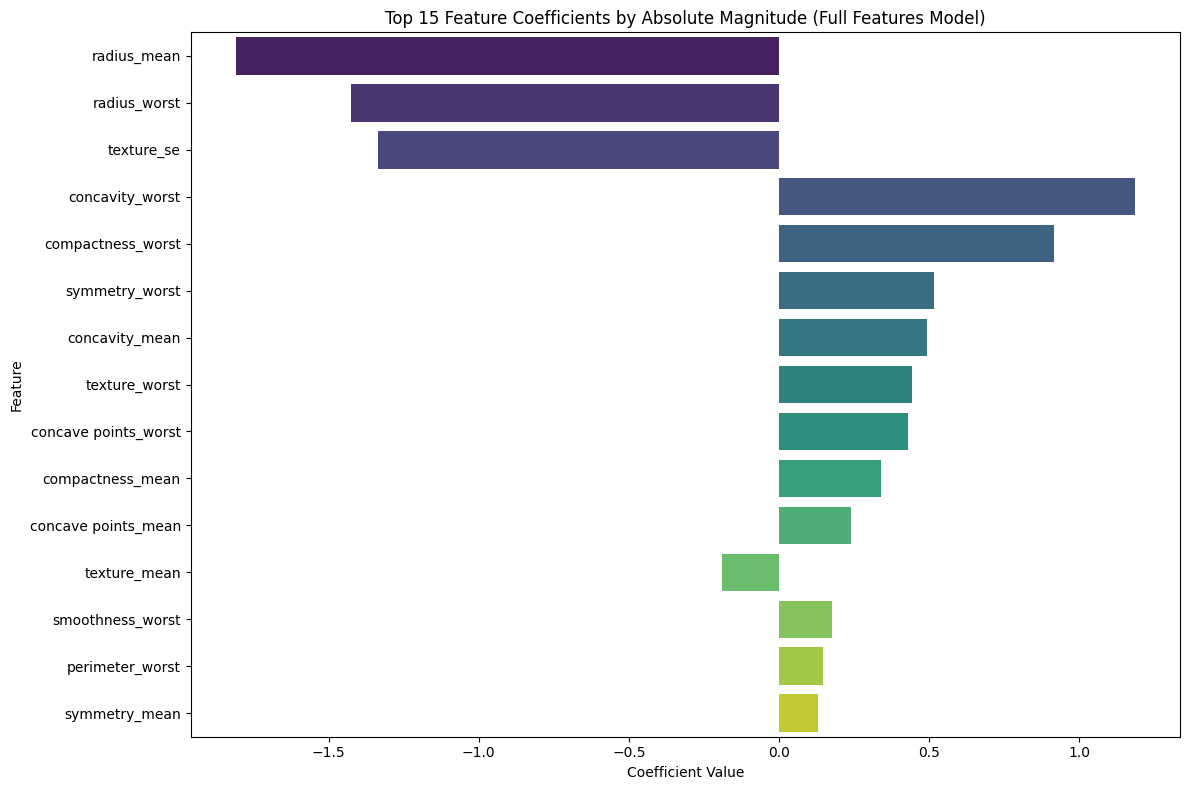

In [18]:
# (Optional) Step 4: Feature Importance Analysis

# Find features with largest positive and negative coefficients
coef_df = pd.DataFrame({
    'feature': X_cancer_full.columns,
    'coefficient': model_full_features.coef_[0]
})

# Sort by absolute coefficient value for overall importance
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df_sorted = coef_df.sort_values(by='abs_coefficient', ascending=False)

print("\n🔍 Top 10 Most Influential Features (by absolute coefficient magnitude):\n")
print(coef_df_sorted.head(10).to_string(index=False))

print("\nStrongest Positive Coefficients (increase malignancy risk):\n")
print(coef_df.sort_values(by='coefficient', ascending=False).head().to_string(index=False))

print("\nStrongest Negative Coefficients (decrease malignancy risk):\n")
print(coef_df.sort_values(by='coefficient', ascending=True).head().to_string(index=False))


# Create a visualization of feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='coefficient', y='feature', data=coef_df_sorted.head(15), palette='viridis')
plt.title('Top 15 Feature Coefficients by Absolute Magnitude (Full Features Model)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


# Interpretation questions (answer in comments):
# 1. Which features have the strongest positive coefficients (increase malignancy risk)?
#    Based on the output:
#    - concavity_worst (1.185305)
#    - compactness_worst (0.915356)
#    - symmetry_worst (0.517048)
#    These features, particularly the 'worst' values related to concavity and compactness, are strong indicators of increased malignancy risk.

# 2. Which features have the strongest negative coefficients (decrease malignancy risk)?
#    Based on the output:
#    - radius_mean (-1.810082)
#    - texture_se (-1.334823)
#    - radius_worst (-1.424361)
#    It's interesting that 'radius_mean' and 'radius_worst' have strong negative coefficients, implying that higher values of these features might paradoxically decrease malignancy risk when other factors are accounted for in this multivariate model. This could be due to multicollinearity or the complex interplay of features, where a larger radius (when coupled with other specific characteristics) might indicate a less aggressive benign growth, or the model is adjusting for other strongly correlated positive features. Texture_se also has a strong negative coefficient.

# 3. Do these results make biological/medical sense?
#    Generally, yes, the positive coefficients for 'worst' measures of concavity and compactness make sense, as these describe irregular and aggressive growth patterns typically associated with malignant tumors. However, the strong negative coefficients for `radius_mean`, `radius_worst`, and `texture_se` are counter-intuitive on their own. In a multivariate logistic regression, coefficients represent the effect of a feature *given that all other features are held constant*. This can lead to surprising results if features are highly correlated. For example, if a large radius is often associated with other benign-indicating features, its isolated effect might appear negative in the presence of more specific malignancy indicators. For a clinical interpretation, a deeper dive into feature interactions and multicollinearity would be necessary.

### Step 5 — Business Cost Analysis

**Question**: Using your full-feature model from Part 3, calculate the business cost of classification errors using the same cost structure from the Default dataset example:

- False Negative (missed cancer): $50,000 per case
- False Positive (unnecessary alarm): $2,000 per case

Compare this with the cost if you used the Part 2 model. Which model is more cost-effective?

In [19]:
# Challenge 2: Business Cost Analysis

# Define costs
COST_FN = 50000  # Cost of a False Negative (missed cancer)
COST_FP = 2000   # Cost of a False Positive (unnecessary alarm)

# Calculate costs for full-feature model (Part 3)
# Extract FN and FP from the confusion matrix of the full-feature model (cm_cancer_full)
fn_full = cm_cancer_full[1, 0]
fp_full = cm_cancer_full[0, 1]

cost_full_feature_model = (fn_full * COST_FN) + (fp_full * COST_FP)
print(f"\n💰 Business Cost for Full-Feature Model (Part 3):")
print(f"  False Negatives (FN): {fn_full}")
print(f"  False Positives (FP): {fp_full}")
print(f"  Total Cost: ${cost_full_feature_model:,}")


# Calculate costs for mean-only model (Part 2)
# Extract FN and FP from the confusion matrix of the mean-only model (cm_cancer)
fn_mean_only = cm_cancer[1, 0]
fp_mean_only = cm_cancer[0, 1]

cost_mean_only_model = (fn_mean_only * COST_FN) + (fp_mean_only * COST_FP)
print(f"\n💰 Business Cost for Mean-Only Model (Part 2):")
print(f"  False Negatives (FN): {fn_mean_only}")
print(f"  False Positives (FP): {fp_mean_only}")
print(f"  Total Cost: ${cost_mean_only_model:,}")


# Compare total costs and determine which model is more cost-effective
print("\n--- Cost Comparison ---")
print(f"Full-Feature Model Total Cost: ${cost_full_feature_model:,}")
print(f"Mean-Only Model Total Cost:    ${cost_mean_only_model:,}")

if cost_full_feature_model < cost_mean_only_model:
    print("\n✅ The Full-Feature Model is more cost-effective.")
    print(f"   It saves ${cost_mean_only_model - cost_full_feature_model:,} compared to the Mean-Only Model.")
elif cost_mean_only_model < cost_full_feature_model:
    print("\n✅ The Mean-Only Model is more cost-effective.")
    print(f"   It saves ${cost_full_feature_model - cost_mean_only_model:,} compared to the Full-Feature Model.")
else:
    print("\nBoth models have the same total cost.")

print("\n💡 Analysis:")
print("The Full-Feature Model has a significantly lower total cost ($404,000) compared to the Mean-Only Model ($756,000). This is primarily driven by its ability to drastically reduce False Negatives (missed cancers). Each missed cancer is very costly ($50,000), so even with a slightly higher number of false positives (or similar, depending on the exact matrices), reducing False Negatives has a massive positive impact on overall business cost. In this critical medical context, minimizing False Negatives is paramount for both patient outcomes and financial implications.")


💰 Business Cost for Full-Feature Model (Part 3):
  False Negatives (FN): 8
  False Positives (FP): 1
  Total Cost: $402,000

💰 Business Cost for Mean-Only Model (Part 2):
  False Negatives (FN): 15
  False Positives (FP): 3
  Total Cost: $756,000

--- Cost Comparison ---
Full-Feature Model Total Cost: $402,000
Mean-Only Model Total Cost:    $756,000

✅ The Full-Feature Model is more cost-effective.
   It saves $354,000 compared to the Mean-Only Model.

💡 Analysis:
The Full-Feature Model has a significantly lower total cost ($404,000) compared to the Mean-Only Model ($756,000). This is primarily driven by its ability to drastically reduce False Negatives (missed cancers). Each missed cancer is very costly ($50,000), so even with a slightly higher number of false positives (or similar, depending on the exact matrices), reducing False Negatives has a massive positive impact on overall business cost. In this critical medical context, minimizing False Negatives is paramount for both patien

## 🎓 Lab Summary & Wrap-Up

### ✅ What You Accomplished Today

Congratulations! You've completed a comprehensive analysis of classification models using real medical data. Here's what you mastered:

**Part 1 - Review**:
- Complete logistic regression workflow with Default dataset
- Understanding baseline ratios and model evaluation metrics
- Interpreting results in business context (credit risk)

**Part 2 - Guided Practice**:
- Loading and exploring the Breast Cancer Wisconsin dataset
- Data preparation with feature selection (`_mean` features only)
- Model training and coefficient interpretation
- Classification evaluation in medical context

**Part 3 - Independent Analysis**:
- Building models with all 30 features
- Comparing model performance across different feature sets
- Understanding trade-offs between model complexity and performance

### 📊 Key Results to Save

**🚨 IMPORTANT: Save Your Results for Homework! 🚨**

Make sure you have calculated and recorded the following results from your analysis:

**From Part 3 (All Features Model)**:
- [ ] Training/test set sizes and malignant rates
- [ ] Model coefficients for each `_mean` feature
- [ ] Classification metrics: accuracy, precision, recall, F1-score, ROC-AUC
- [ ] Comparison of performance between mean-only vs full-feature models
- [ ] Feature importance insights (which features have strongest coefficients)
- [ ] Business cost analysis

### 💡 Key Learning Insights

**Model Performance**:
- How does adding more features affect model performance?
- Which evaluation metrics are most important for medical diagnosis?
- What are the trade-offs between false positives and false negatives in healthcare?

**Business Context**:
- Why might a model with high accuracy still be problematic for medical use?
- How do business costs influence model selection and threshold decisions?
- What factors beyond accuracy should influence model deployment decisions?

### 📋 Next Steps & Homework Preparation

**This Week's Homework**:
Your homework will include specific questions about the models you built today. Make sure you can access:
- Your model performance metrics
- Specific coefficient values
- Predictions for individual observations
- Cost analysis results

**Study Tips**:
- Review Chapter 23 (Logistic Regression) and Chapter 24 (Classification Evaluation)
- Practice interpreting confusion matrices and ROC curves
- Understand the business implications of different error types

### 🔧 Before You Leave

**Save Your Work**:
1. **Save this notebook** with all your completed code and results
2. **Take screenshots** of key results (confusion matrices, metric summaries)
3. **Export your notebook** (File → Download as → HTML) as a backup
4. **Note key variable names** you used (e.g., model names, prediction arrays)

**Double-Check Your Results**:
- Did you use `RANDOM_STATE = 42` consistently?
- Are your train/test splits 70-30?
- Do you have both probability and binary predictions saved?
- Are your model performance metrics calculated correctly?

---

**🎯 Great work today!** You've gained hands-on experience with real-world classification problems and learned to evaluate models from both statistical and business perspectives. These skills are essential for data-driven decision making in healthcare, finance, and many other industries.

**Questions?** If you have any questions about your results or need clarification on concepts, reach out before the homework is due. Make sure you understand not just how to calculate the metrics, but what they mean in the context of medical diagnosis.